In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

def last_noNaN_index(serie):
    return((~np.isnan(serie.flatten())).cumsum(0).argmax(0))

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

# df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
# df_tracks= df.pivot(values=[
#     'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
#     'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
#     'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
#     'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
#     'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
#     'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
#     index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
#     columns='Time')

X_train shape	 (32706, 96, 1) 	 X_test shape	 (583, 96, 1)


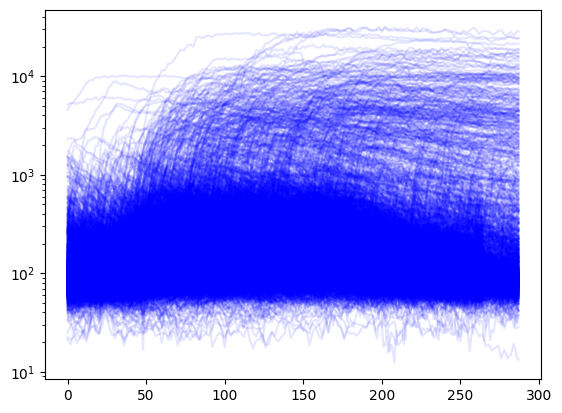

In [2]:
### Creating dataset and splitting it into train and test sets then data augmentation
# liste_x=[]
# liste_y=[]

# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']

# for exp_name in dataset_name_list:

#     medium,treatment,replicate = exp_name.split('_')

#     frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
#     size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
#     cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
#     sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
#     mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

#     DeathSubtype = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])

#     for i in range(size_array.shape[0]):
#         ##fill nans missing timepoints with the mean of the previous and next timepoints
#         size_serie =  size_array[i]
#         for j in range(1,len(size_serie)-1):
#             if np.isnan(size_serie[j]):
#                 size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

#         sos_serie = sos_array[i]
#         for j in range(1,len(sos_serie)-1):
#             if np.isnan(sos_serie[j]):
#                 sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
#         mcherry_serie = mcherry_array[i]
#         for j in range(1,len(mcherry_serie)-1):
#             if np.isnan(mcherry_serie[j]):
#                 mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

#         cyclefate_serie = cyclefate_array[i]
#         for j in range(len(cyclefate_serie)-1):
#             if cyclefate_serie[j] == 'nan':
#                 cyclefate_serie[j] = cyclefate_serie[j+1]

#         t_death = len(cyclefate_serie)
#         if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
#             t_death = np.where(cyclefate_serie != 'alive')[0][0]

#         # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
#         first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

#         if first_NaN>96:
#             last_usable_timepoint = min(first_NaN,288)
#             liste_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
#             liste_y.append((medium,treatment,replicate,t_death,DeathSubtype[i]))
# #scan for NANs in all liste_x
# for x in liste_x:
#     for serie in x:
#         if np.sum(np.isnan(serie))>0:
#             print('NAN found')

# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_x_SOS_training.npy',np.array(liste_x,dtype=object))
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_y_SOS_training.npy',np.array(liste_y,dtype=object))

liste_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_x_SOS_training.npy',allow_pickle=True)
liste_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_y_SOS_training.npy',allow_pickle=True)

X_train_preaug, X_test_preaug, y_train_preaug, y_test_preaug = train_test_split(liste_x, liste_y, test_size=0.1, random_state=42, shuffle=True)
#### data augmentation
##### in X_train we change each sequence to series of size 96 with a roling window of 12
liste_x_train = []
liste_y_train = []
for i in range(len(X_train_preaug)):
    usable_data = X_train_preaug[i][1] #using only the SOS signal
    for j in range(0, len(usable_data) - 96 + 1, 12):
        liste_x_train.append(usable_data[j:j+96])
        liste_y_train.append(y_train_preaug[i])
X_train = TimeSeriesScalerMeanVariance().fit_transform(np.log(np.array(liste_x_train)))
# X_train = MinMaxScaler(feature_range=(0, 1)).fit_transform(np.log(np.array(liste_x_train)))[:,:,np.newaxis]
y_train = np.array(liste_y_train)

# In X_test we cut each sequence into unique 96-long sequences
liste_x_test = []
liste_y_test = []
for i in range(len(X_test_preaug)):
    usable_data = X_test_preaug[i][1]
    for j in range(0, len(usable_data) - 96 + 1, 96):
        liste_x_test.append(usable_data[j:j + 96])
        liste_y_test.append(y_test_preaug[i])
X_test = TimeSeriesScalerMeanVariance().fit_transform(np.log(np.array(liste_x_test)))
# X_test = MinMaxScaler(feature_range=(0, 1)).fit_transform(np.log(np.array(liste_x_test)))[:,:,np.newaxis]

y_test = np.array(liste_y_test)

train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

for s  in  [x[1] for x in liste_x]:
    plt.plot(s,alpha=0.1,color='blue')
plt.yscale('log')

print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

In [ ]:
## training cell
# replicate = 0
# t0 = time.time()

# sequence_length = X_train.shape[1]
# number_of_features = X_train.shape[2]

# dload = './model_dir_mm' #download directory
# hidden_size = 90
# hidden_layer_depth = 2
# batch_size = 200
# learning_rate = 0.001 # 0.0005
# n_epochs = 200
# dropout_rate = 0.2
# optimizer = 'Adam' # options: ADAM, SGD
# cuda = True # options: True, False
# print_every=1000
# clip = True # options: True, False
# max_grad_norm=5
# loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
# block = 'LSTM' # options: LSTM, GRU


# for latent_length in range(20,2-1,-1):
#     print('latent_length\t',latent_length,'\t elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

#     vrae = VRAE(sequence_length=sequence_length,
#                 number_of_features = number_of_features,
#                 hidden_size = hidden_size, 
#                 hidden_layer_depth = hidden_layer_depth,
#                 latent_length = latent_length,
#                 batch_size = batch_size,
#                 learning_rate = learning_rate,
#                 n_epochs = n_epochs,
#                 dropout_rate = dropout_rate,
#                 optimizer = optimizer, 
#                 cuda = cuda,
#                 print_every=print_every, 
#                 clip=clip, 
#                 max_grad_norm=max_grad_norm,
#                 loss = loss,
#                 block = block,
#                 dload = dload)

#     vrae.fit(train_dataset, test_dataset, save=True)

#     file = open(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\print.txt').readlines()
#     train_losses = []
#     test_losses = []
#     for line in file:
#         if 'Average loss' in line:
#             train_losses.append(float(line.split(' ')[-2]))
#             test_losses.append(float(line.split(' ')[-1][:-2]))
#             # print(float(line.split(' ')[-2]),float(line.split(' ')[-1][:-2]))

#     shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_minmax\model_{replicate}_{latent_length}.pth')
#     shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model_best.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_minmax\model_best_{replicate}_{latent_length}.pth')
#     np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_minmax\train_losses_{replicate}_{latent_length}.npy', train_losses)
#     np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_minmax\test_losses_{replicate}_{latent_length}.npy', test_losses)
###277m 4h37

latent_length	 20 	 elapsed time	 1.6649564107259113e-05  minutes	 2.7749273512098526e-07  hours
Epoch: 0
Average loss: 397.0262
Epoch: 1
Average loss: 287.9057
Epoch: 2
Average loss: 328.3008
Epoch: 3
Average loss: 372.4268
Epoch: 4
Average loss: 349.3292
Epoch: 5
Average loss: 446.5138
Epoch: 6
Average loss: 291.5066
Epoch: 7
Average loss: 290.9670
Epoch: 8
Average loss: 315.7000
Epoch: 9
Average loss: 390.4967
Epoch: 10
Average loss: 216.5142
Epoch: 11
Average loss: 132.3040
Epoch: 12
Average loss: 117.5117
Epoch: 13
Average loss: 104.8447
Epoch: 14
Average loss: 94.1848
Epoch: 15
Average loss: 94.2444
Epoch: 16
Average loss: 70.6595
Epoch: 17
Average loss: 73.3495
Epoch: 18
Average loss: 54.7479
Epoch: 19
Average loss: 53.1875
Epoch: 20
Average loss: 50.2142
Epoch: 21
Average loss: 53.2754
Epoch: 22
Average loss: 48.7225
Epoch: 23
Average loss: 45.7696
Epoch: 24
Average loss: 55.3558
Epoch: 25
Average loss: 47.4411
Epoch: 26
Average loss: 44.5153
Epoch: 27
Average loss: 41.9905
Epo

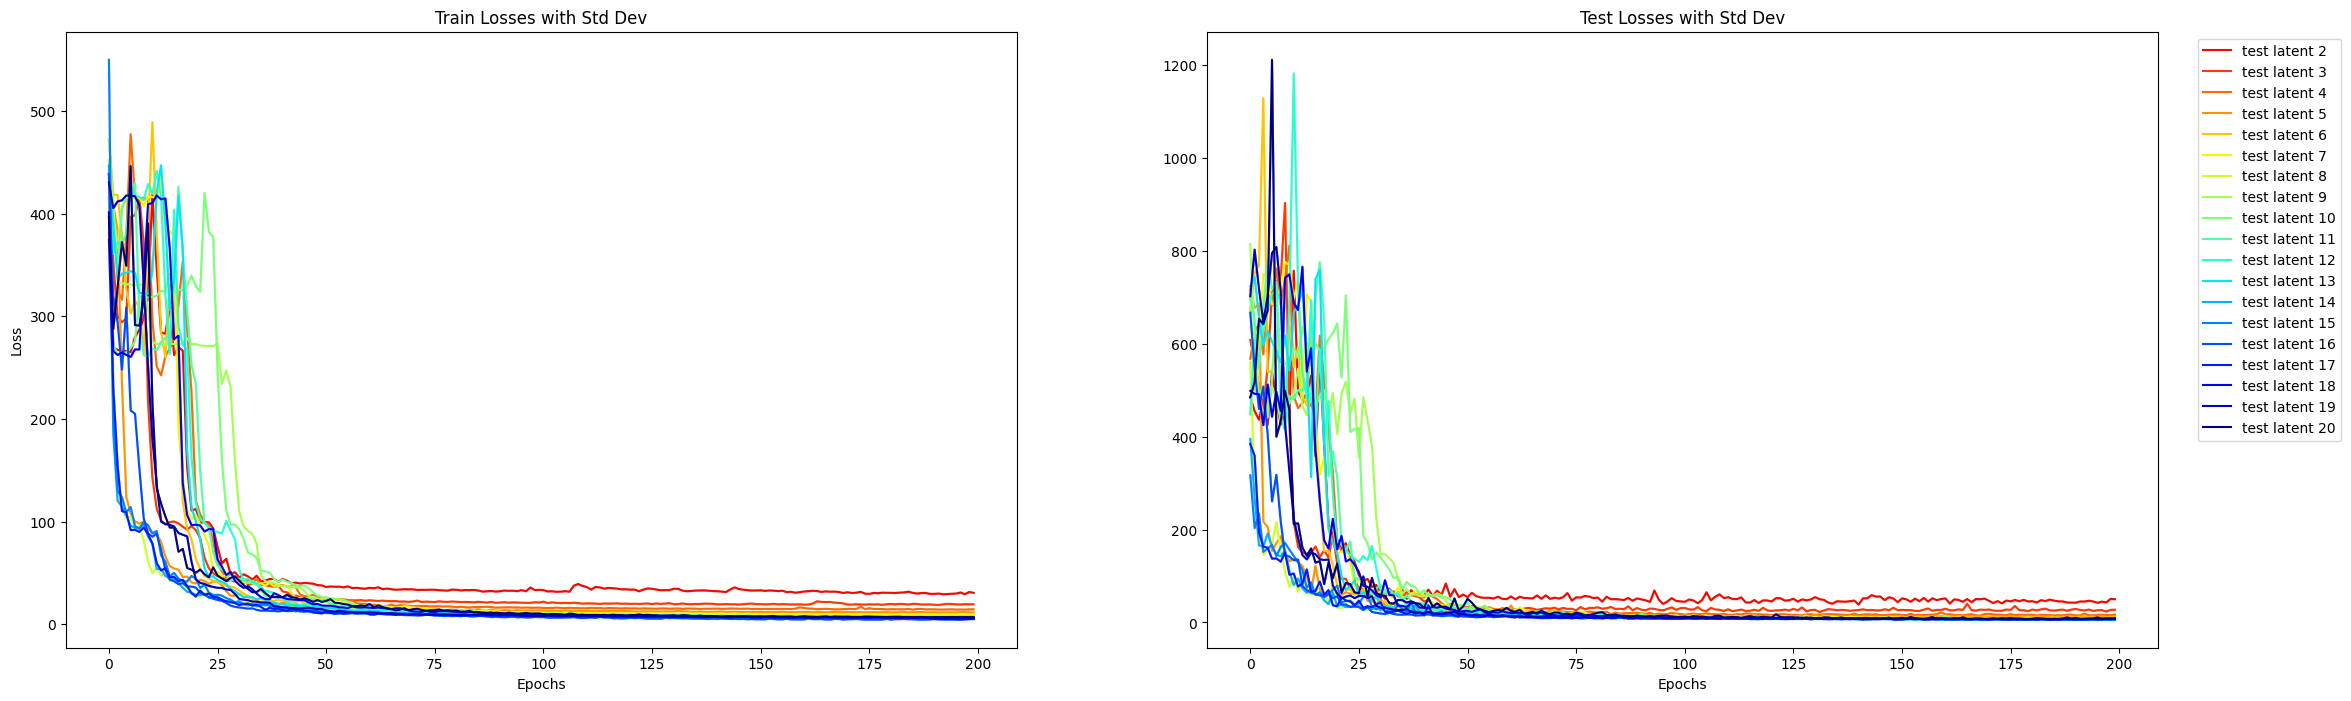

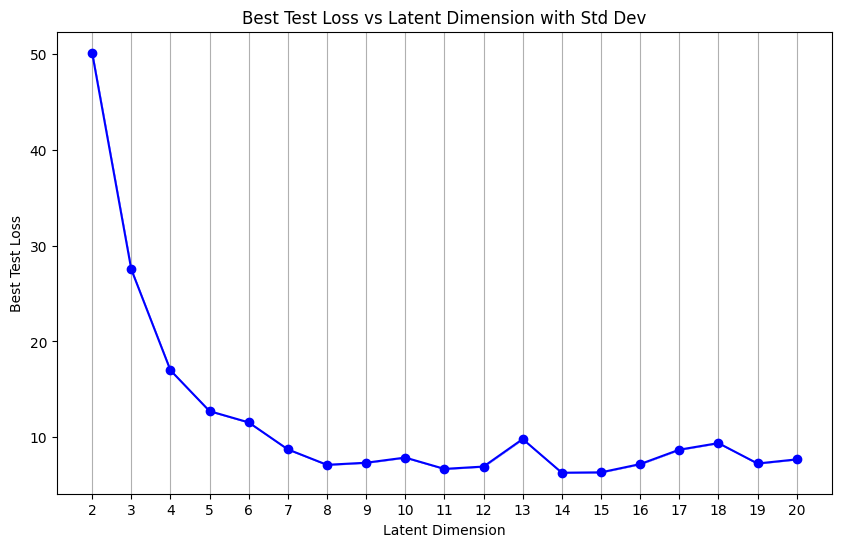

In [300]:
## trainig curves minmax
n_replicate = 1
path=fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_minmax'
loss_dict = {}
for latent_length in range(2, 21):
    loss_dict[latent_length] = ([],[])
    for replicate in range(n_replicate):
        train_losses = np.load(fr'{path}\train_losses_{replicate}_{latent_length}.npy')
        test_losses = np.load(fr'{path}\test_losses_{replicate}_{latent_length}.npy')
        loss_dict[latent_length][0].append(train_losses)
        loss_dict[latent_length][1].append(test_losses)

# plot mean train loss and mean test loss with std curves+fill as a function of latent dimension using loss_dict 
mean_train_losses = np.zeros((19,200))
mean_test_losses = np.zeros((19,200))
std_train_losses = np.zeros((19,200))
std_test_losses = np.zeros((19,200))

for latent_length in range(2, 21):
    mean_train_losses[latent_length-2] = np.mean(loss_dict[latent_length][0], axis=0)
    mean_test_losses[latent_length-2] = np.mean(loss_dict[latent_length][1], axis=0)
    std_train_losses[latent_length-2] = np.std(loss_dict[latent_length][0], axis=0)
    std_test_losses[latent_length-2] = np.std(loss_dict[latent_length][1], axis=0)

fig,ax = plt.subplots(1,2,figsize=(27,8))
cmap = plt.get_cmap('jet')
for latent_length in range(2, 21):
    ax[0].plot(mean_train_losses[latent_length-2], label=f'train latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[0].fill_between(range(200), 
                       mean_train_losses[latent_length-2]-std_train_losses[latent_length-2], 
                       mean_train_losses[latent_length-2]+std_train_losses[latent_length-2], 
                       color=cmap((20-latent_length)/20), alpha=0.3)
    ax[1].plot(mean_test_losses[latent_length-2], label=f'test latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[1].fill_between(range(200), 
                       mean_test_losses[latent_length-2]-std_test_losses[latent_length-2], 
                       mean_test_losses[latent_length-2]+std_test_losses[latent_length-2], 
                       color=cmap((20-latent_length)/20), alpha=0.3)
    ax[0].set_title('Train Losses with Std Dev')
    ax[1].set_title('Test Losses with Std Dev')
    ax[0].set_xlabel('Epochs')
    ax[1].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# plot best test loss with std curves+fill as a function of latent dimension
std_test_losses = []
best_test_loss = []
for latent_length in range(2, 21):
    test_losses = loss_dict[latent_length][1]
    best_losses = np.min(np.array(test_losses)[:,-1])
    std_loss = np.std(np.array(test_losses)[:,-1])
    best_test_loss.append(best_losses)
    std_test_losses.append(std_loss)
plt.figure(figsize=(10,6))
plt.plot(range(2, 21), best_test_loss, marker='o', label='Best Test Loss', color='blue')
plt.fill_between(range(2, 21), 
                 np.array(best_test_loss)-np.array(std_test_losses), 
                 np.array(best_test_loss)+np.array(std_test_losses), 
                 color='blue', alpha=0.3, label='Std Dev')
plt.xticks(range(2, 21))
plt.title('Best Test Loss vs Latent Dimension with Std Dev')
plt.xlabel('Latent Dimension')
plt.ylabel('Best Test Loss')
plt.grid(axis='x')

best_replicate_15 = np.argmin([arr[-1] for arr in loss_dict[15][1]]) #3


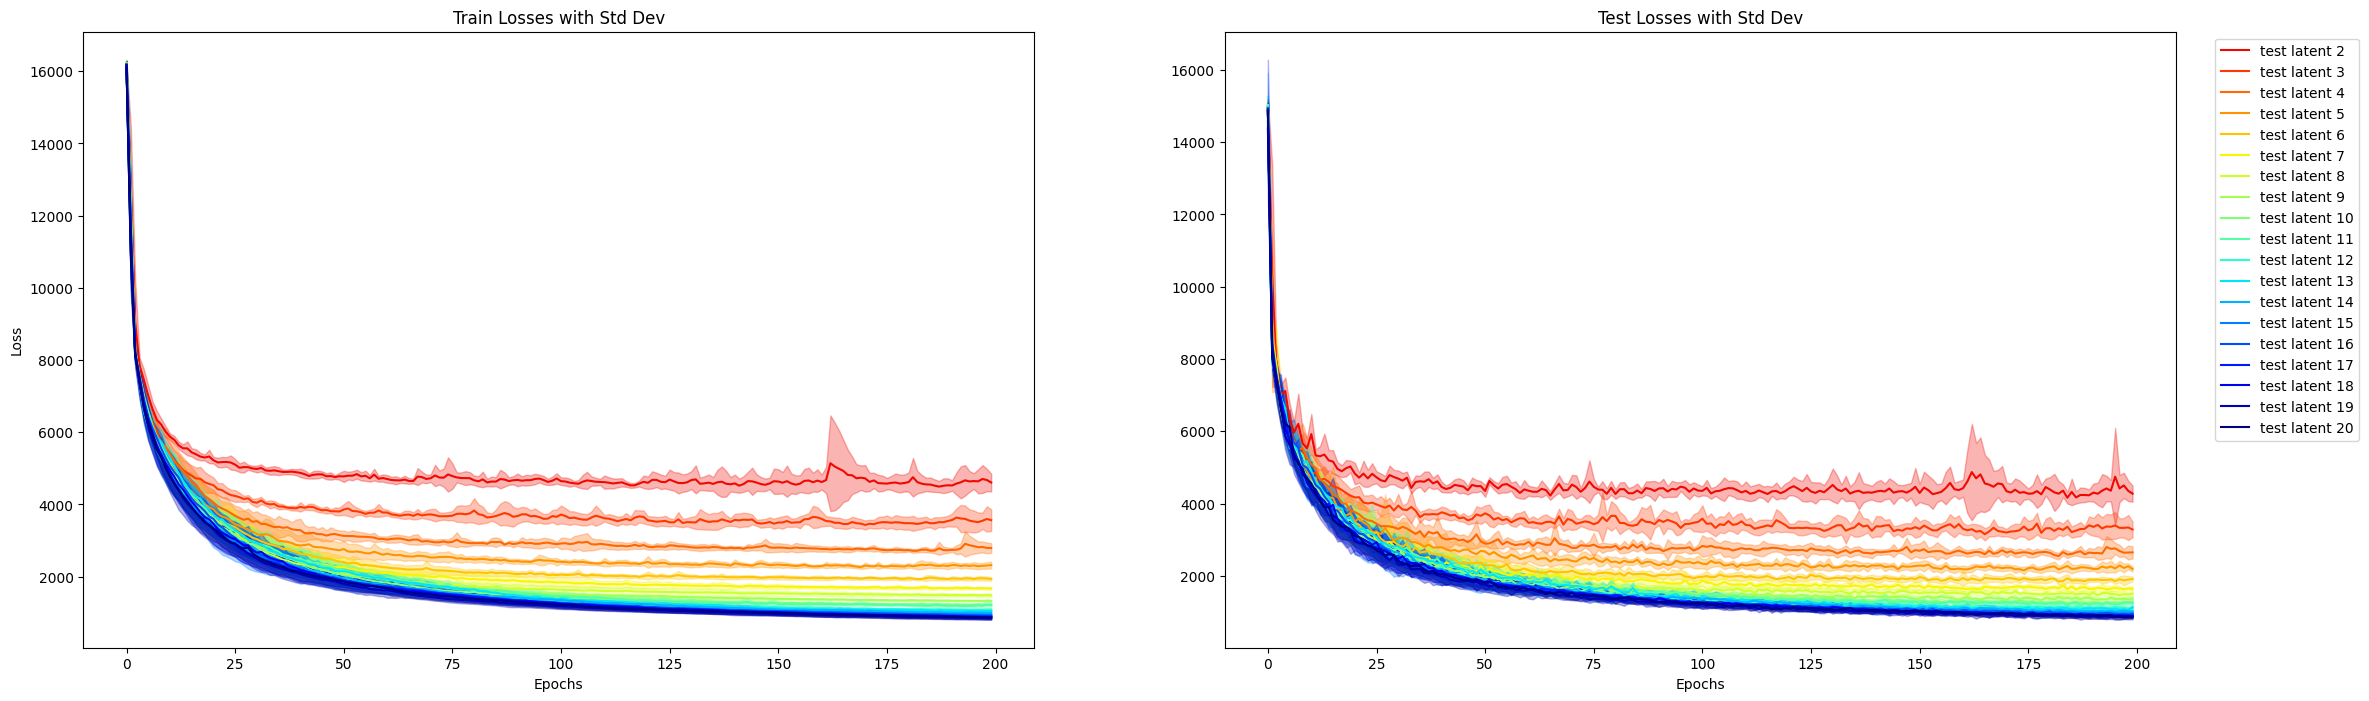

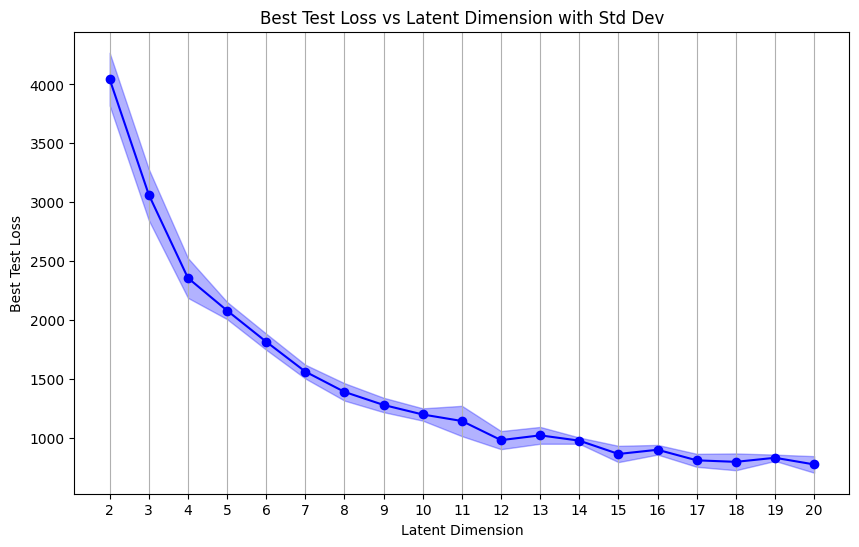

In [ ]:
## trainig curves
n_replicate = 9
path=fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos'
loss_dict = {}
for latent_length in range(2, 21):
    loss_dict[latent_length] = ([],[])
    for replicate in range(n_replicate):
        train_losses = np.load(fr'{path}\train_losses_{replicate}_{latent_length}.npy')
        test_losses = np.load(fr'{path}\test_losses_{replicate}_{latent_length}.npy')
        loss_dict[latent_length][0].append(train_losses)
        loss_dict[latent_length][1].append(test_losses)

# plot mean train loss and mean test loss with std curves+fill as a function of latent dimension using loss_dict 
mean_train_losses = np.zeros((19,200))
mean_test_losses = np.zeros((19,200))
std_train_losses = np.zeros((19,200))
std_test_losses = np.zeros((19,200))

for latent_length in range(2, 21):
    mean_train_losses[latent_length-2] = np.mean(loss_dict[latent_length][0], axis=0)
    mean_test_losses[latent_length-2] = np.mean(loss_dict[latent_length][1], axis=0)
    std_train_losses[latent_length-2] = np.std(loss_dict[latent_length][0], axis=0)
    std_test_losses[latent_length-2] = np.std(loss_dict[latent_length][1], axis=0)

fig,ax = plt.subplots(1,2,figsize=(27,8))
cmap = plt.get_cmap('jet')
for latent_length in range(2, 21):
    ax[0].plot(mean_train_losses[latent_length-2], label=f'train latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[0].fill_between(range(200), 
                       mean_train_losses[latent_length-2]-std_train_losses[latent_length-2], 
                       mean_train_losses[latent_length-2]+std_train_losses[latent_length-2], 
                       color=cmap((20-latent_length)/20), alpha=0.3)
    ax[1].plot(mean_test_losses[latent_length-2], label=f'test latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[1].fill_between(range(200), 
                       mean_test_losses[latent_length-2]-std_test_losses[latent_length-2], 
                       mean_test_losses[latent_length-2]+std_test_losses[latent_length-2], 
                       color=cmap((20-latent_length)/20), alpha=0.3)
    ax[0].set_title('Train Losses with Std Dev')
    ax[1].set_title('Test Losses with Std Dev')
    ax[0].set_xlabel('Epochs')
    ax[1].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# plot best test loss with std curves+fill as a function of latent dimension
std_test_losses = []
best_test_loss = []
for latent_length in range(2, 21):
    test_losses = loss_dict[latent_length][1]
    best_losses = np.min(np.array(test_losses)[:,-1])
    std_loss = np.std(np.array(test_losses)[:,-1])
    best_test_loss.append(best_losses)
    std_test_losses.append(std_loss)
plt.figure(figsize=(10,6))
plt.plot(range(2, 21), best_test_loss, marker='o', label='Best Test Loss', color='blue')
plt.fill_between(range(2, 21), 
                 np.array(best_test_loss)-np.array(std_test_losses), 
                 np.array(best_test_loss)+np.array(std_test_losses), 
                 color='blue', alpha=0.3, label='Std Dev')
plt.xticks(range(2, 21))
plt.title('Best Test Loss vs Latent Dimension with Std Dev')
plt.xlabel('Latent Dimension')
plt.ylabel('Best Test Loss')
plt.grid(axis='x')

best_replicate_15 = np.argmin([arr[-1] for arr in loss_dict[15][1]]) #3

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.



torch.Size([96, 200, 1])
138


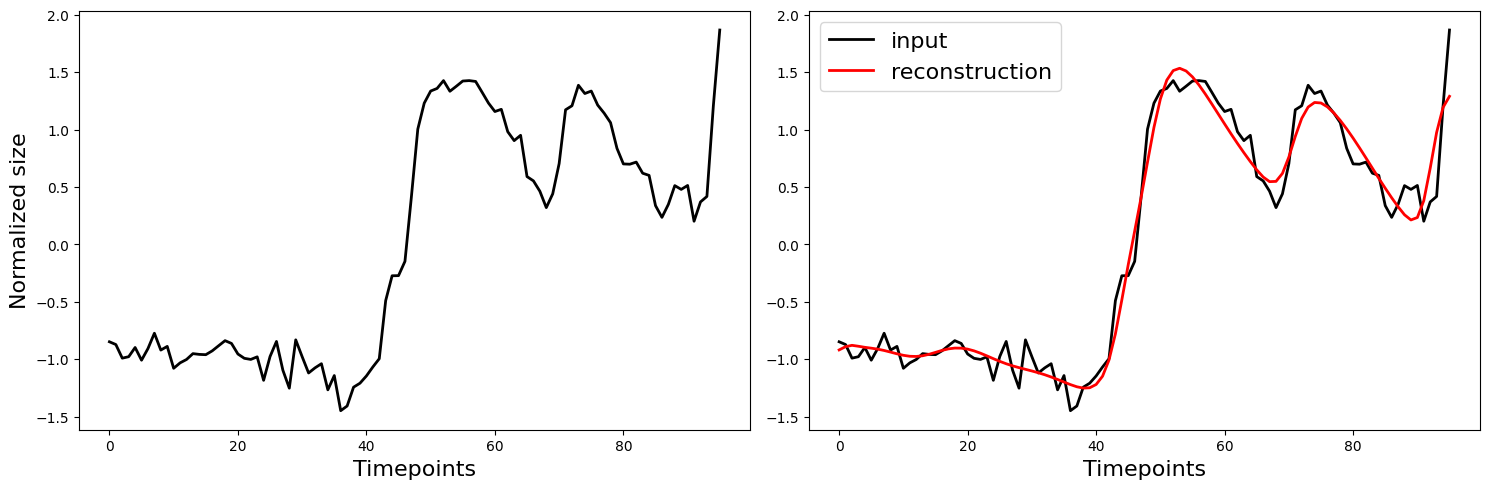

In [3]:
## load model 15 3
sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]

dload = './model_save' #model save directory
latent_length = 15
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001
n_epochs = 2 #200
dropout_rate = 0.2
optimizer = 'Adam'
cuda = True
print_every=1000
clip = True
max_grad_norm=5
loss = 'MSELoss'
block = 'LSTM'

vrae_trained = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\model_best_3_{latent_length}.pth')
# vrae_trained.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_minmax\model_best_0_{15}.pth')

vrae_trained.eval()
testseq2 = test_dataset[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)
outp = vrae_trained.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
k=31
input_seq = testseq2[:,k,0].cpu().detach().numpy()
output_seq = outp[0][:,k,0].cpu().detach().numpy()

fig,ax =  plt.subplots(1,2,figsize=(15,5))
ax[0].plot(input_seq.T, color ='black',linewidth = 2, label='input')
ax[1].plot(input_seq.T, color ='black',linewidth = 2, label='input')
ax[1].plot(output_seq.T, color='red',linewidth = 2, label='reconstruction')
ax[0].set_xlabel('Timepoints', fontsize=16)
ax[0].set_ylabel('Normalized size', fontsize=16)
ax[1].set_xlabel('Timepoints', fontsize=16)
# ax[0].set_title('Reconstruction of a test sequence', fontsize=16)
ax[1].legend(fontsize=16)
plt.tight_layout()

Total dataset size	 8087
['gly' 'control' '1' 569 '2058435' 'survived']


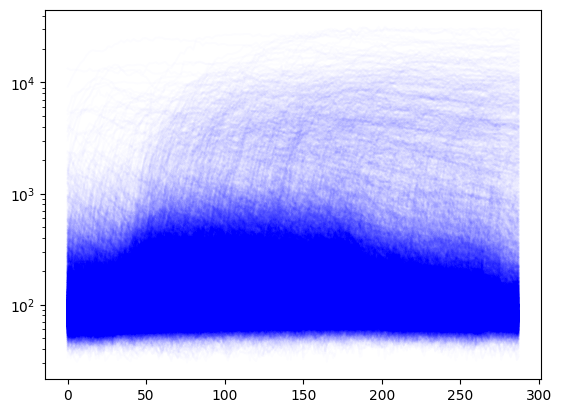

In [4]:
#### import literally everything
# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1'] training set
dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
 'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']


# all_data_x=[]
# all_data_y=[]

# for exp_name in dataset_name_list:

#     medium,treatment,replicate = exp_name.split('_')

#     frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
#     size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
#     cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
#     sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
#     mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

#     DeathSubtypes = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])
#     Fates = np.array([i for i in frame.reset_index('fate')['fate']])

#     for i in range(size_array.shape[0]):
#         ##fill nans missing timepoints with the mean of the previous and next timepoints
#         size_serie =  size_array[i]
#         for j in range(1,len(size_serie)-1):
#             if np.isnan(size_serie[j]):
#                 size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

#         sos_serie = sos_array[i]
#         for j in range(1,len(sos_serie)-1):
#             if np.isnan(sos_serie[j]):
#                 sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
#         mcherry_serie = mcherry_array[i]
#         for j in range(1,len(mcherry_serie)-1):
#             if np.isnan(mcherry_serie[j]):
#                 mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

#         cyclefate_serie = cyclefate_array[i]
#         for j in range(len(cyclefate_serie)-1):
#             if cyclefate_serie[j] == 'nan':
#                 cyclefate_serie[j] = cyclefate_serie[j+1]

#         t_death = len(cyclefate_serie)
#         if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
#             t_death = np.where(cyclefate_serie != 'alive')[0][0]

#         # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
#         first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

#         if first_NaN>96:
#             last_usable_timepoint = min(first_NaN,288)
#             all_data_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
#             all_data_y.append((medium,treatment,replicate,t_death,DeathSubtypes[i],Fates[i]))
# #scan for NANs in all all_data_x
# for x in all_data_x:
#     for serie in x:
#         if np.sum(np.isnan(serie))>0:
#             print('NAN found')

# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_x_SOS.npy',np.array(all_data_x,dtype=object))
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_y_SOS.npy',np.array(all_data_y,dtype=object))
## 1m48

all_data_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_x_SOS.npy',allow_pickle=True)
all_data_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_y_SOS.npy',allow_pickle=True)

index_to_remove =[6,7,8,9,10,18,43,44,45,46,47,2974,2975,2976,3135,3136,3137,3138,3139,3140,3141,3142,3143,3144,3145,5415,5538,5710,5711,5712,5713,5714,5715,5716] #after manual inspection
all_data_x = np.delete(all_data_x, index_to_remove, axis=0)
all_data_y = np.delete(all_data_y, index_to_remove, axis=0)

# pad data with NaNs to make them all the same length, then log and scale then cut them back to original length
max_length = max([x[1].shape[0] for x in all_data_x])
padded_data = np.array([np.pad(x[1], (0, max_length - x[1].shape[0]), mode='constant', constant_values=np.NaN) for x in all_data_x])

padded_data_scaled = TimeSeriesScalerMeanVariance().fit_transform(np.log(padded_data))
# padded_data_scaled = MinMaxScaler(feature_range=(0, 1)).fit_transform(np.log(padded_data))[:,:,np.newaxis]


all_data_x_sos_scaled = [padded_data_scaled[i][:all_data_x[i][1].shape[0]] for i in range(len(all_data_x))]

for s  in  [x[1] for x in all_data_x]:
    plt.plot(s,alpha=0.01,color='blue')
plt.yscale('log')
print('Total dataset size\t',len(all_data_x))
print(all_data_y[0])

Text(0.5, 0, 'Time series length (in hours)')

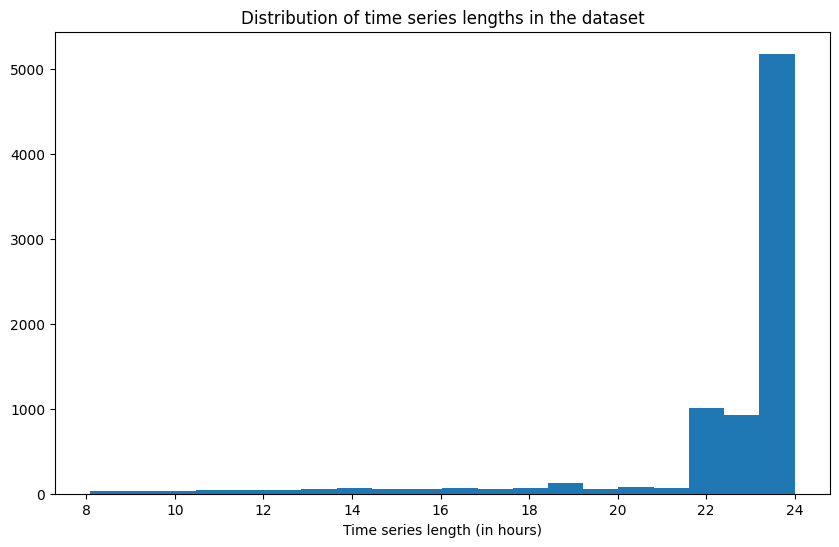

In [34]:
#lengths histogram
plt.figure(figsize=(10,6))
plt.hist([len(x[1])/12 for x in all_data_x], bins=20)
# l = plt.hist([len(x[1]) for x in all_data_x], bins=200)
# plt.xticks(range(0, 301, 12))
plt.title('Distribution of time series lengths in the dataset')
plt.xlabel('Time series length (in hours)')

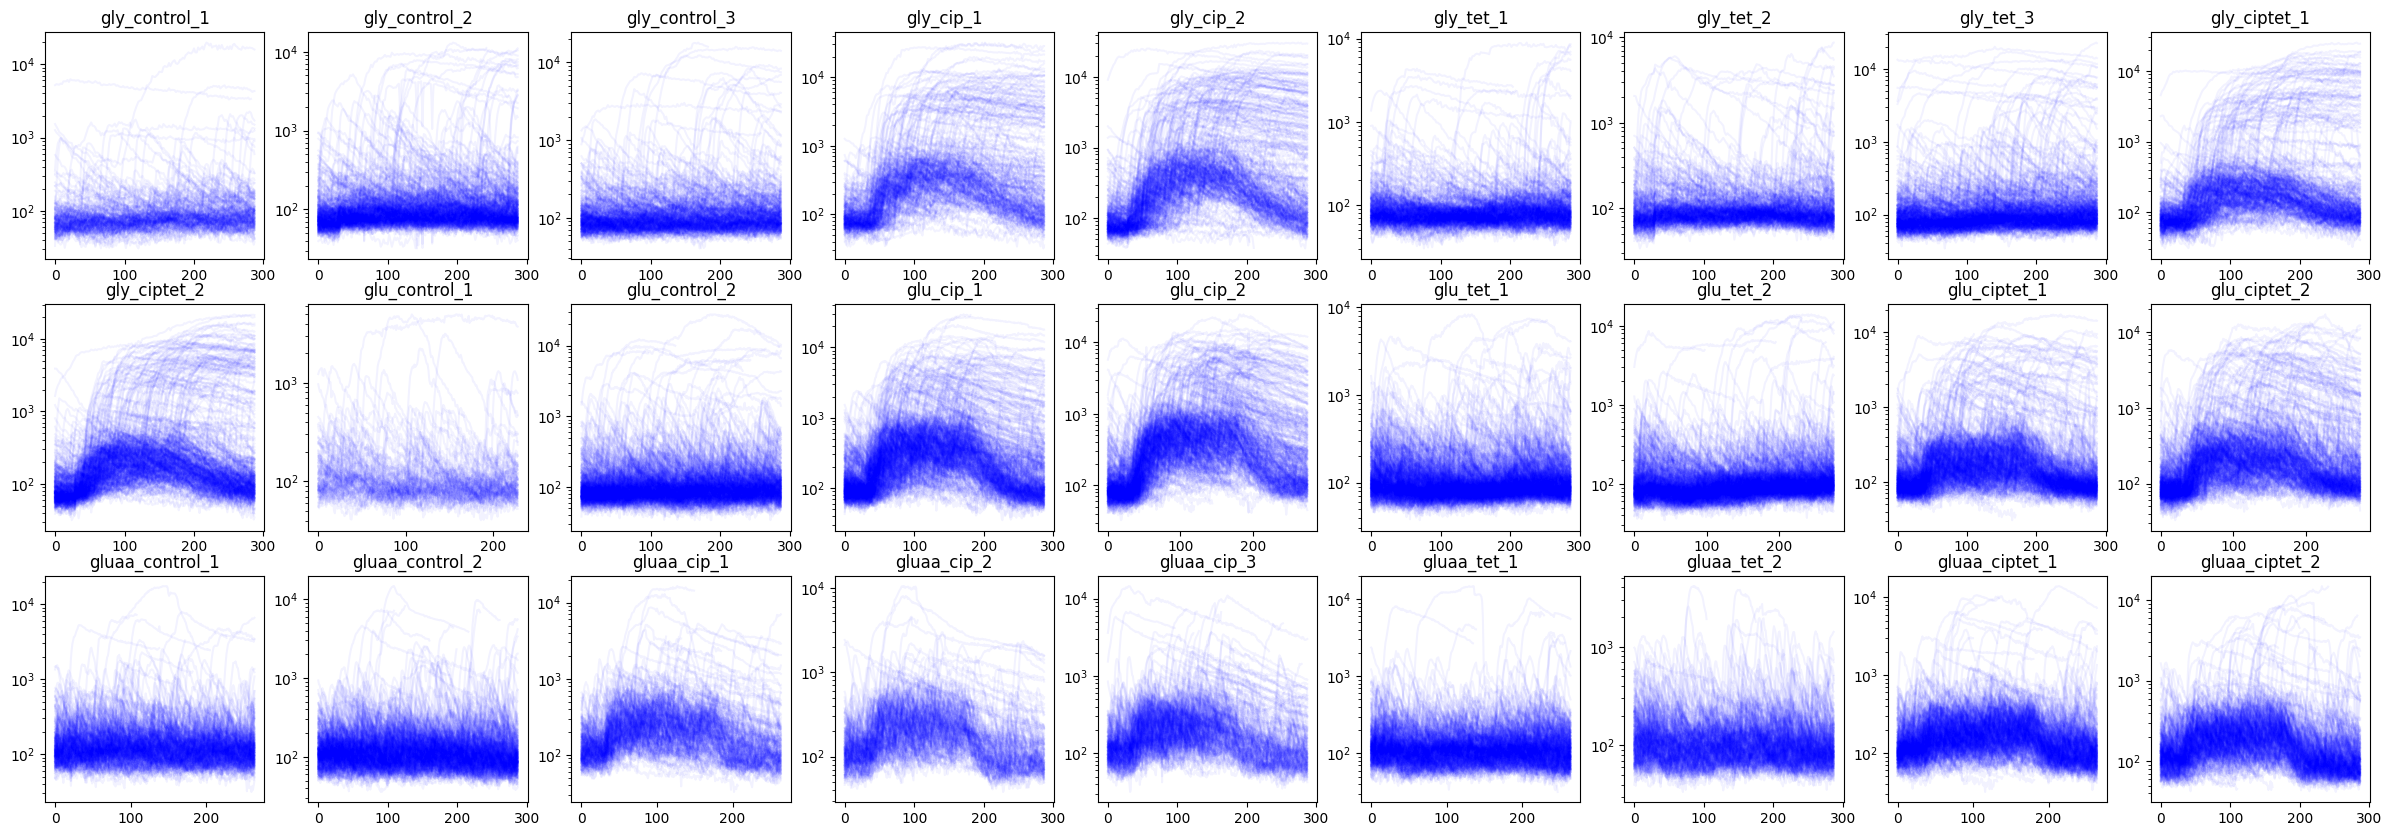

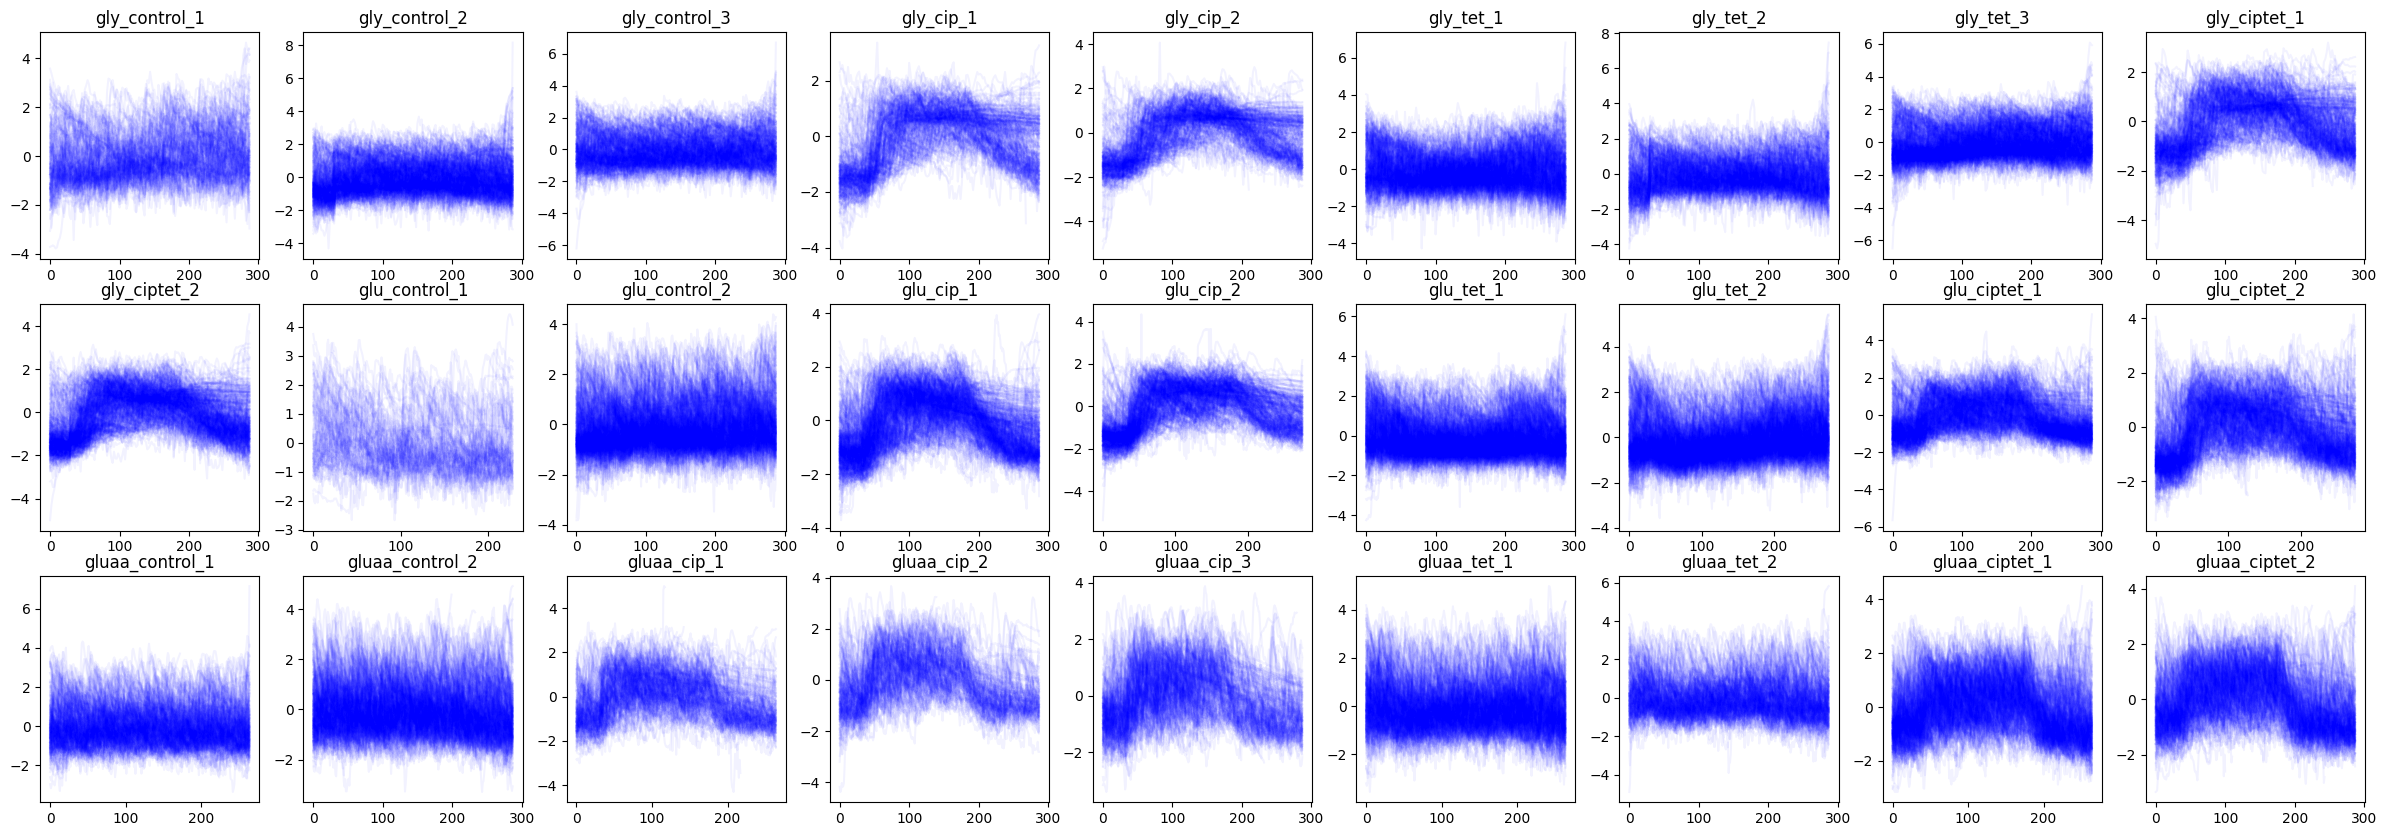

In [8]:
## data inspection after logging and scaling
fig,ax = plt.subplots(3,9,figsize=(30,10))
# ax.flatten()
for i in range(27):
    ax.flatten()[i].set_title(dataset_name_list[i])
    medium,treatment,replicate = dataset_name_list[i].split('_')
    ax.flatten()[i].plot(np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
    ax.flatten()[i].set_yscale('log')

fig,ax = plt.subplots(3,9,figsize=(30,10))
# ax.flatten()
for i in range(27):
    ax.flatten()[i].set_title(dataset_name_list[i])
    medium,treatment,replicate = dataset_name_list[i].split('_')
    ax.flatten()[i].plot(np.array([padded_data_scaled[j,:,0] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)

5798


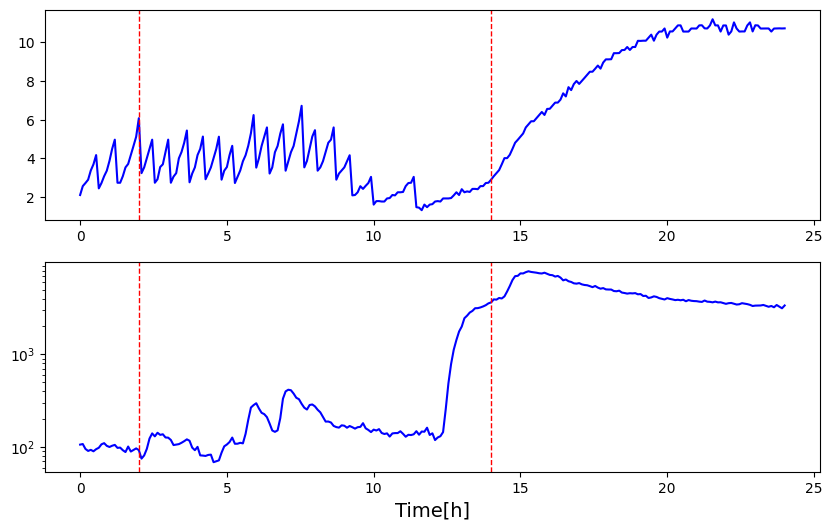

In [35]:
# medium,treatment,replicate = 'glu','cip','1'
# time = np.linspace(0,24,288)
# plt.figure(figsize=(10,6))
# plt.plot(time,np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] )[0].T,color='blue',alpha=1)
# plt.yscale('log')
# plt.title(f'{medium}_{treatment}_{replicate}', fontsize=16)
# plt.xlabel('Time[h]', fontsize=14)
# plt.ylabel('Log(SOS Response)', fontsize=14)
# plt.tight_layout()
# plt.ylim(0,20000)
# # plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
# # plt.axvline(x=14, color='red', linestyle='--', linewidth=1)

k=np.random.randint(0,len(all_data_x))
k=5798
print(k)
fig,ax = plt.subplots(2,1,figsize=(10,6))
time = np.linspace(0,24,265)
ax[0].plot(time,all_data_x[k][0],color='blue',alpha=1)
ax[1].set_yscale('log')
ax[1].plot(time,all_data_x[k][1],color='blue',alpha=1)
ax[1].set_xlabel('Time[h]', fontsize=14)
#vertical lines at 2 and 14 hours
ax[1].axvline(x=2, color='red', linestyle='--', linewidth=1)
ax[1].axvline(x=14, color='red', linestyle='--', linewidth=1)
ax[0].axvline(x=2, color='red', linestyle='--', linewidth=1)
ax[0].axvline(x=14, color='red', linestyle='--', linewidth=1)


array([1.9267 , 1.8578 , 1.7889 , 1.8677 , 1.9465 , 2.0961 , 2.2457 ,
       2.2542 , 2.2627 , 2.334  , 2.4053 , 2.48515, 2.565  , 2.64485,
       2.7247 , 2.74335, 2.762  , 2.0645 , 1.367  , 1.4875 , 1.608  ,
       1.56295, 1.5179 , 1.5748 , 1.6317 , 1.6317 , 1.6317 , 1.7103 ,
       1.7889 , 1.8578 , 1.9267 , 1.847  , 1.7673 , 1.9267 , 2.0861 ,
       2.0163 , 1.9465 , 2.0255 , 2.1045 , 2.1045 , 2.1045 , 2.1751 ,
       2.2457 , 2.3255 , 2.4053 , 2.41325, 2.4212 , 2.57295, 2.7247 ,
       2.8112 , 2.8977 , 3.05085, 3.204  , 2.33955, 1.4751 , 1.54155,
       1.608  , 1.68765, 1.7673 , 1.7673 , 1.7673 , 1.7781 , 1.7889 ,
       1.8677 , 1.9465 , 2.0163 , 2.0861 , 2.1104 , 2.1347 , 2.1902 ,
       2.2457 , 2.3255 , 2.4053 , 2.41325, 2.4212 , 2.50055, 2.5799 ,
       2.81205, 3.0442 , 2.1818 , 1.3194 , 1.3194 , 1.3194 , 1.39725,
       1.4751 , 1.54155, 1.608  , 1.54155, 1.4751 , 1.6212 , 1.7673 ,
       1.847  , 1.9267 , 1.9267 , 1.9267 , 2.0064 , 2.0861 , 2.0163 ,
       1.9465 , 2.02

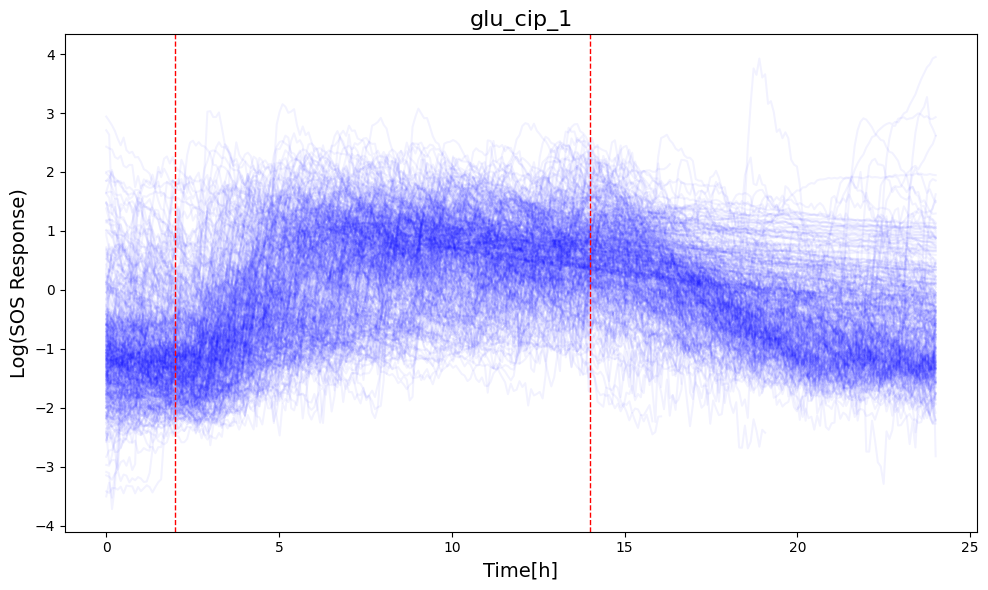

In [10]:
#plot one experiment change timepoints with time
medium,treatment,replicate = 'glu','cip','1'
time = np.linspace(0,24,288)
plt.figure(figsize=(10,6))
plt.plot(time,np.array([padded_data_scaled[j,:,0] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
# plt.yscale('log')
plt.title(f'{medium}_{treatment}_{replicate}', fontsize=16)
plt.xlabel('Time[h]', fontsize=14)
plt.ylabel('Log(SOS Response)', fontsize=14)
plt.tight_layout()
# plt.ylim(0,20000)
plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
plt.axvline(x=14, color='red', linestyle='--', linewidth=1)


# # plot only series that survived
# plt.figure(figsize=(10,6))
# plt.plot(time,np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate and all_data_y[j][-1]=='survived' ] ).T,color='grey',alpha=0.1)
# plt.yscale('log')
# plt.title(f'{medium}_{treatment}_{replicate} survived', fontsize=16)
# plt.xlabel('Time[h]', fontsize=14)
# plt.ylabel('Log(SOS Response)', fontsize=14)
# plt.tight_layout()
# plt.ylim(0,20000)
# plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
# plt.axvline(x=14, color='red', linestyle='--', linewidth=1)

# # plot only series that didnt survived
# plt.figure(figsize=(10,6))
# plt.plot(time,np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate and all_data_y[j][-1]!='survived' ] ).T,color='red',alpha=0.1)
# plt.yscale('log')
# plt.title(f'{medium}_{treatment}_{replicate} died', fontsize=16)
# plt.xlabel('Time[h]', fontsize=14)
# plt.ylabel('Log(SOS Response)', fontsize=14)
# plt.tight_layout()
# plt.ylim(0,20000)
# plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
# plt.axvline(x=14, color='red', linestyle='--', linewidth=1)


# # plot only series that low inducer
# plt.figure(figsize=(10,6))
# plt.plot(time,np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate and all_data_y[j][-2] =='LowInducer' ] ).T,color='magenta',alpha=0.1)
# plt.yscale('log')
# plt.title(f'{medium}_{treatment}_{replicate} LowInducer', fontsize=16)
# plt.xlabel('Time[h]', fontsize=14)
# plt.ylabel('Log(SOS Response)', fontsize=14)
# plt.tight_layout()
# plt.ylim(0,20000)
# plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
# plt.axvline(x=14, color='red', linestyle='--', linewidth=1)


# # plot only series that high inducer
# plt.figure(figsize=(10,6))
# plt.plot(time,np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate and all_data_y[j][-2] =='HighInducer' ] ).T,color='orange',alpha=0.1)
# plt.yscale('log')
# plt.title(f'{medium}_{treatment}_{replicate} HighInducer', fontsize=16)
# plt.xlabel('Time[h]', fontsize=14)
# plt.ylabel('Log(SOS Response)', fontsize=14)
# plt.tight_layout()
# plt.ylim(0,20000)
# plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
# plt.axvline(x=14, color='red', linestyle='--', linewidth=1)


In [ ]:
# inspection code
# target_name = "gly_control_1"
# medium, treatment, replicate = target_name.split('_')

# indices = [idx for idx, y in enumerate(all_data_y) if y[0] == medium and y[1] == treatment and y[2] == replicate]

# for i in range(0, len(indices), 3):
#     fig, axs = plt.subplots(1, 3, figsize=(18, 4))
#     for j in range(3):
#         if i + j < len(indices):
#             idx = indices[i + j]
#             axs[j].plot(padded_data_scaled[idx, :, 0], color='blue', alpha=0.7)
#             axs[j].set_title(f'Index: {idx}')
#             axs[j].set_xlabel('Time')
#             axs[j].set_ylabel('Scaled SOS')
#             axs[j].set_ylim(-4, 4)
#         else:
#             axs[j].axis('off')
#     plt.tight_layout()
#     plt.show()

In [12]:
# encode everything

def encode_sequence_1dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def forward_sequence_1dim(vrae_model, sequence):
    if sequence.shape[0]>vrae_model.sequence_length:
        print(f'Sequence not {vrae_model.sequence_length}')
        return(-1)
    vrae_model.eval()
    fake_batch_200 = np.tile(sequence, (200, 1)).T
    fake_batch_200 = torch.from_numpy(fake_batch_200).float().unsqueeze(2).cuda()
    reconstruction = vrae_model.forward(fake_batch_200)
    return reconstruction[0][:,0,:].cpu().detach().numpy()

latent_all = []
vrae_trained.eval()
vrae_trained.batch_size = 1
for seq in [x[:,0] for x in all_data_x_sos_scaled]: #[x[1] for x in all_data_x]: #
    latent = encode_sequence_1dim(vrae_trained, seq)
    latent_all.append(latent)
latent_all = np.array(latent_all)




latent_all_trunc = []
all_data_y_trunc = []
vrae_trained.eval()
vrae_trained.batch_size = 1
for i,seq in enumerate([x[:,0] for x in all_data_x_sos_scaled]): #[x[1] for x in all_data_x]: #
    if seq.shape[0]>=264: #cutting to 264 timepoints (22h) to have all sequences of same length
        seq = seq[:264]
        latent = encode_sequence_1dim(vrae_trained, seq)
        latent_all_trunc.append(latent)
        all_data_y_trunc.append(all_data_y[i])
print(len(all_data_x_sos_scaled))
print('Total dataset size\t',len(all_data_y_trunc))
latent_all = np.array(latent_all_trunc)
# all_data_y = np.array(all_data_y_trunc)

8087
Total dataset size	 7089


5291


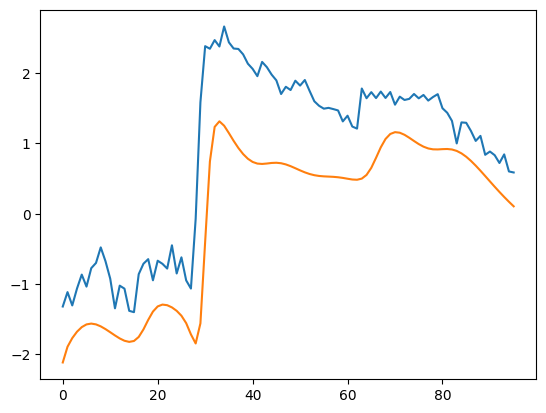

In [43]:
k=np.random.randint(0,len(all_data_x_sos_scaled))
print(k)
seqplot = all_data_x_sos_scaled[k][:96,0]
plt.plot(seqplot)
plt.plot(forward_sequence_1dim(vrae_trained, seqplot))
# plt.ylim(0,4)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(-15.0, 15.0)

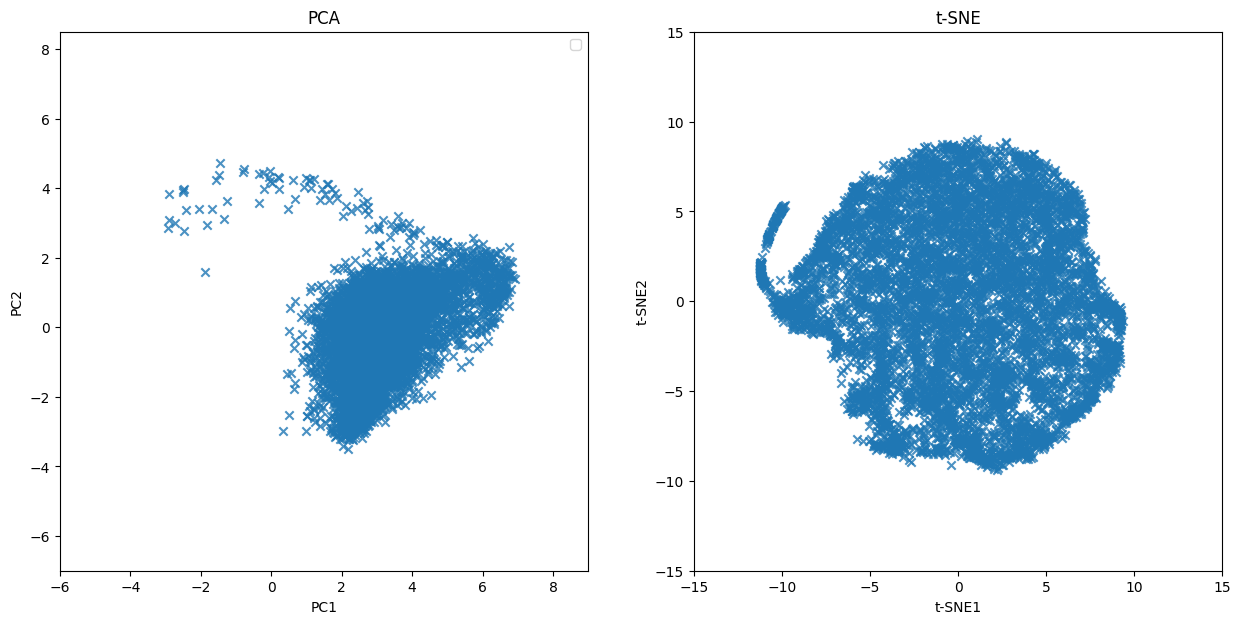

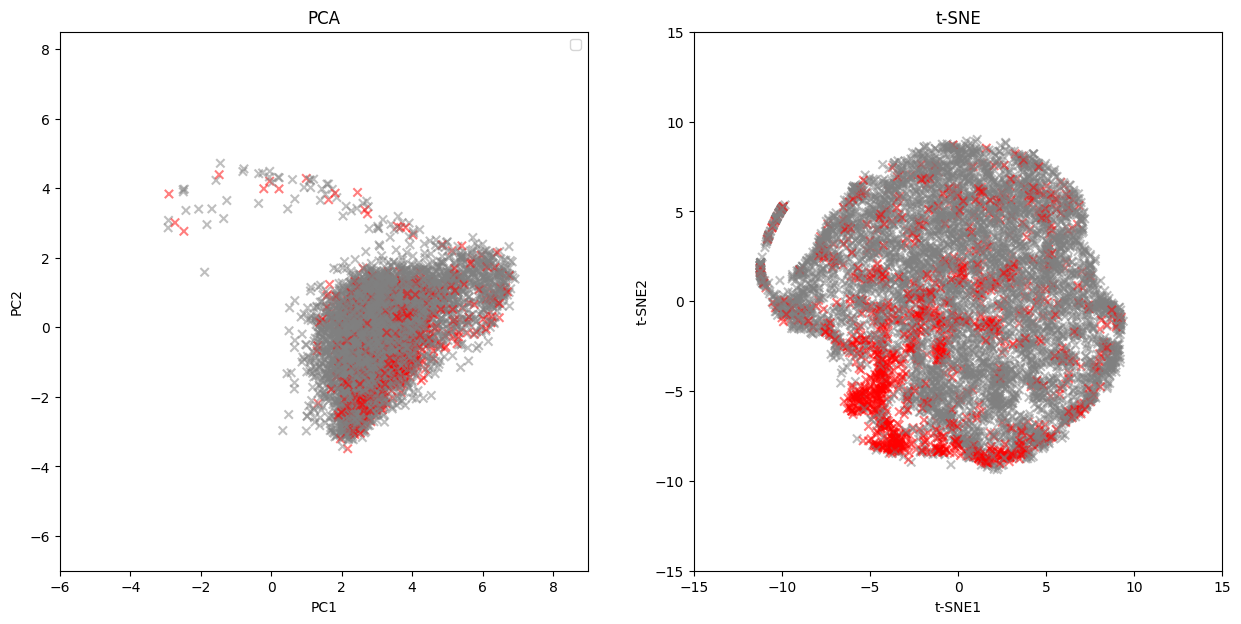

In [14]:
from sklearn.decomposition import TruncatedSVD,PCA
from sklearn.manifold import TSNE



# whole data pca
latent_length = 15
z_run = latent_all
z_run_pca_fit = TruncatedSVD(n_components=latent_length).fit(z_run)
z_run_pca = z_run_pca_fit.transform(z_run)
z_run_tsne = TSNE(perplexity=40, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

ylims = (-7,8.5)
xlims = (-6,9)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], marker='x',alpha=0.8)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], marker='x',alpha=0.8)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(ylims[0],ylims[1])
ax[0].set_xlim(xlims[0],xlims[1])
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)

hex_colors =  {0:'red', 1:'grey'}
colors = [hex_colors[y[-1]=='survived'] for y in all_data_y]
colors = [hex_colors[y[-1]=='survived'] for y in all_data_y_trunc]
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], color=colors, marker='x',alpha=0.5)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], color=colors, marker='x',alpha=0.5)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(ylims[0],ylims[1])
ax[0].set_xlim(xlims[0],xlims[1])
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)


## color time series using a jet colormap based on their length
# norm = plt.Normalize(0, 1)
# cmap = plt.get_cmap("jet")
# colors = [cmap(norm(len(x[1])-100)) for x in all_data_x]
#  = [len(x[1]) for x in all_data_x]

# colors = ['cyan']*len(all_data_y)
# for i in range(len(all_data_x)):
#     if len(all_data_x[i][1])<288:
#         colors[i] = 'pink'
# fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], color=colors, marker='x',alpha=0.5)
# ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], color=colors, marker='x',alpha=0.5)
# ax[0].legend()
# ax[0].set_title('PCA')
# ax[0].set_xlabel('PC1')
# ax[0].set_ylabel('PC2')
# ax[0].set_ylim(ylims[0],ylims[1])
# ax[0].set_xlim(xlims[0],xlims[1])
# ax[1].set_title('t-SNE')
# ax[1].set_xlabel('t-SNE1')
# ax[1].set_ylabel('t-SNE2')
# ax[1].set_ylim(-15,15)
# ax[1].set_xlim(-15,15)
# # add colorbar

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(-15.0, 15.0)

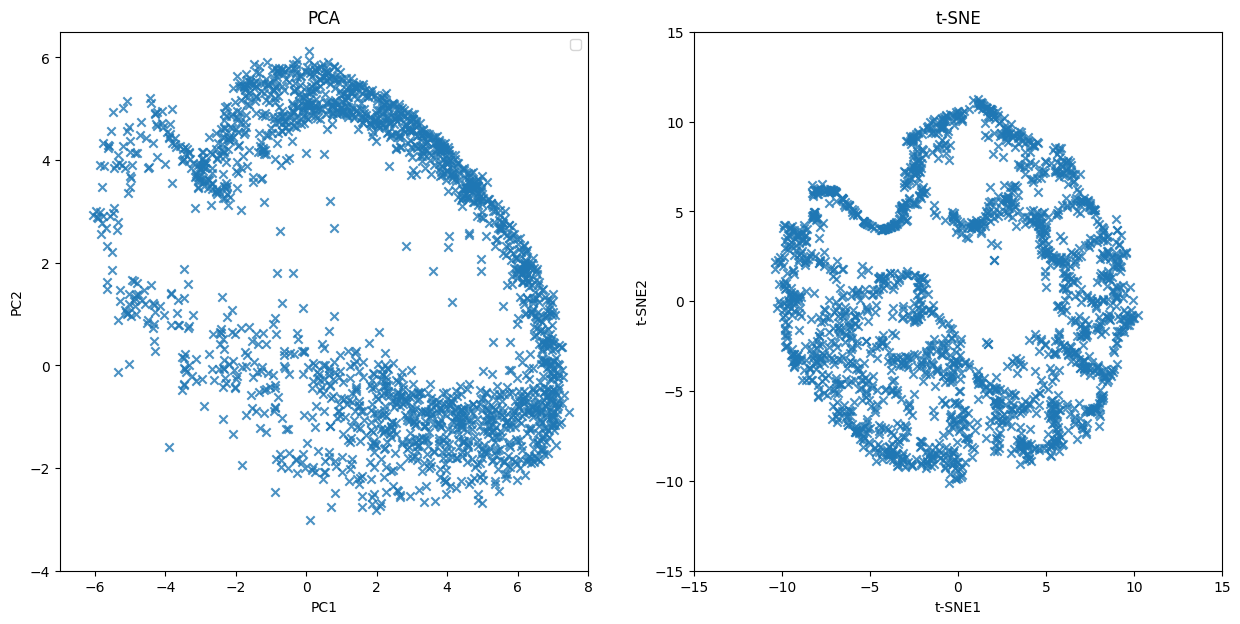

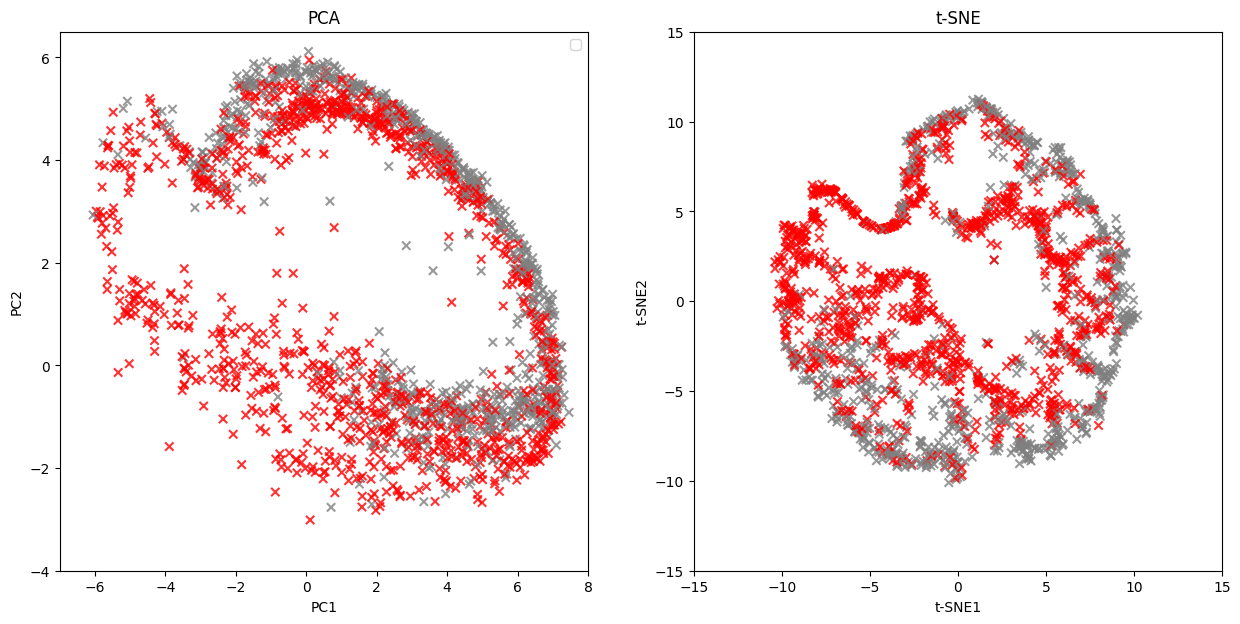

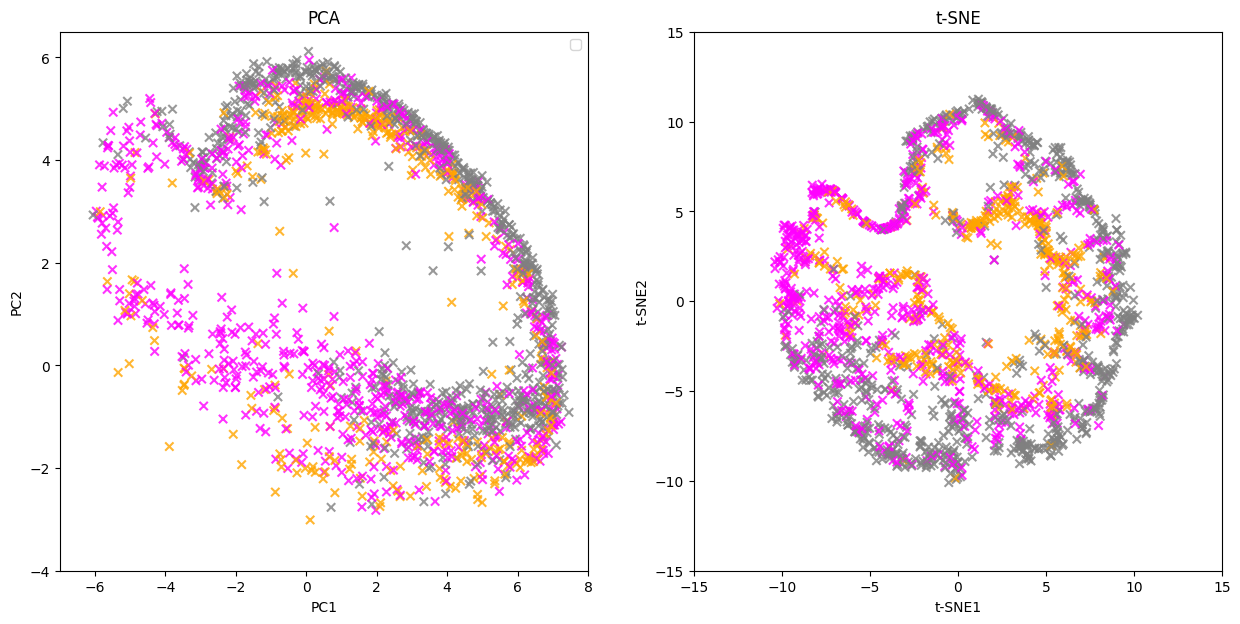

In [57]:
all_data_cip = latent_all[[i for i in range(len(all_data_y)) if all_data_y[i][1]=='cip']]
all_data_cip_y = all_data_y[[i for i in range(len(all_data_y)) if all_data_y[i][1]=='cip']]

latent_length = 15
z_run = all_data_cip
z_run_pca_fit = TruncatedSVD(n_components=latent_length).fit(z_run)
z_run_pca = z_run_pca_fit.transform(z_run)
z_run_tsne = TSNE(perplexity=40, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], marker='x',alpha=0.8)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], marker='x',alpha=0.8)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(-4,6.5)
ax[0].set_xlim(-7,8)
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)


hex_colors =  {0:'red', 1:'grey'}
colors = [hex_colors[y[-1]=='survived'] for y in all_data_cip_y]
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], color=colors, marker='x',alpha=0.8)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], color=colors, marker='x',alpha=0.8)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(-4,6.5)
ax[0].set_xlim(-7,8)
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)

colors = []
for y in all_data_cip_y:
    if y[4]=="LowInducer":
        colors.append('magenta')
    elif y[4]=="HighInducer":
        colors.append('orange')
    else:
        colors.append('grey')
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], color=colors, marker='x',alpha=0.8)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], color=colors, marker='x',alpha=0.8)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(-4,6.5)
ax[0].set_xlim(-7,8)
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)

In [ ]:
all_data_cip_y